In [15]:
import time

import requests
# import selenium
import pandas as pd
from bs4 import BeautifulSoup as bs
time.sleep(2)

Using pygetwindow (Cross-platform, simpler)

In [16]:
import pygetwindow as gw

# Get the currently active window
active_window = gw.getActiveWindow()
print(f"Title: {active_window.title}")
print(f"Position: {active_window.left}, {active_window.top}")
print(f"Size: {active_window.width}x{active_window.height}")

Title: Hell Let Loose  
Position: 0, 0
Size: 2560x1440


Using pywin32 (Windows-specific, more control)

In [17]:
import win32gui

# Get the currently active window handle
hwnd = win32gui.GetForegroundWindow()
window_title = win32gui.GetWindowText(hwnd)
print(f"Active window: {window_title}")

Active window: Hell Let Loose  


Using psutil (For process information)

In [18]:
import psutil
import win32gui
import win32process

hwnd = win32gui.GetForegroundWindow()
_, pid = win32process.GetWindowThreadProcessId(hwnd)
process = psutil.Process(pid)
print(f"Process name: {process.name()}")
print(f"Window title: {win32gui.GetWindowText(hwnd)}")

Process name: HLL-Win64-Shipping.exe
Window title: Hell Let Loose  


In [19]:
import pygetwindow as gw
from pygetwindow import PyGetWindowException

window = gw.getWindowsWithTitle('Hell Let Loose')[0]

try:
    window.activate()
except PyGetWindowException as e:
    # The window was likely activated despite the error
    if "Error code from Windows: 0" in str(e):
        pass  # Ignore this specific error
    else:
        raise

let's try to get elevation from hell let loose rather than guess


In [1]:
# first lets print mouse position when it clicks
import pyautogui
def print_mouse_position(x, y):
    print(f"Mouse clicked at: ({x}, {y})")
while True:
    x, y = pyautogui.position()
    print_mouse_position(x, y)
    time.sleep(5)

# Mouse clicked at: (2282, 1257)
# Mouse clicked at: (2475, 1275)

Mouse clicked at: (1217, 1142)


NameError: name 'time' is not defined

In [4]:
import pytesseract
from PIL import ImageGrab, Image
import cv2
import numpy as np

# Add this line - adjust path if your installation differs
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def capture_screen_region(x, y, width, height):
    """Capture a specific region of the screen"""
    bbox = (x, y, x + width, y + height)
    screenshot = ImageGrab.grab(bbox)
    return screenshot

def preprocess_image_for_ocr(image):
    """Preprocess image to improve OCR accuracy"""
    # Convert PIL image to OpenCV format
    img_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    # Convert to grayscale
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

    # Apply threshold to get black text on white background
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    # Optional: Apply some noise reduction
    # denoised = cv2.fastNlMeansDenoising(thresh)
    denoised = cv2.medianBlur(thresh, 3)

    return Image.fromarray(denoised)

def read_elevation_from_screen(x, y, width, height):
    """Read elevation value from specific screen coordinates"""
    # Capture the region
    screenshot = capture_screen_region(x, y, width, height)


    # Increase the size of the screenshot (scale by 3x)
    screenshot = screenshot.resize((screenshot.width * 3, screenshot.height * 3), Image.LANCZOS)


    # Preprocess for better OCR
    processed = preprocess_image_for_ocr(screenshot)

    # Configure Tesseract to only recognize digits
    custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789MIL'

    # Extract text
    text = pytesseract.image_to_string(processed, config=custom_config)
    print(f"OCR Result: '{text.strip()}'")
    # Parse the elevation value
    try:
        elevation = int(''.join(filter(str.isdigit, text)))
        return elevation
    except ValueError:
        return None

def get_game_elevation():
    # Adjust coordinates based on where elevation appears on your screen
    x, y, width, height = 2399, 1260, 100, 30

    elevation = read_elevation_from_screen(x, y, width, height)
    if elevation is not None:
        print(f"Detected elevation: {elevation} MIL")
        return elevation
    else:
        print("Failed to read elevation from screen")
        return None

def get_game_degree():
    x, y, width, height = 1267, 1375, 26, 21
    degree = read_elevation_from_screen(x, y, width, height)
    if degree is not None:
        print(f"Detected degree: {degree}°")
        return degree
    else:
        print("Failed to read degree from screen")
        return None
get_game_elevation()
get_game_degree()

OCR Result: '705MIL'
Detected elevation: 705 MIL
OCR Result: '276'
Detected degree: 276°


276

Saved original capture to: captured_region.png
Saved preprocessed capture to: processed_region.png

Original capture:


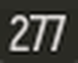


Processed for OCR:


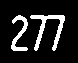

OCR Result: '277'
Extracted text: '277'


In [6]:
def verify_screen_capture(x, y, width, height):
    """Capture and display the screen region to verify coordinates"""
    # Capture the region
    screenshot = capture_screen_region(x, y, width, height)
    screenshot = screenshot.resize((screenshot.width * 3, screenshot.height * 3), Image.LANCZOS)

    # Save the original capture
    screenshot.save("captured_region.png")
    print(f"Saved original capture to: captured_region.png")

    # Also save the preprocessed version
    processed = preprocess_image_for_ocr(screenshot)
    processed.save("processed_region.png")
    print(f"Saved preprocessed capture to: processed_region.png")

    # Display the image (if using Jupyter)
    from IPython.display import display
    print("\nOriginal capture:")
    display(screenshot)
    print("\nProcessed for OCR:")
    display(processed)

    return screenshot

# Test with your current coordinates
# x, y, width, height = 1217, 1142, 85, 25
x, y, width, height = 1267, 1375, 26, 21
verify_screen_capture(x, y, width, height)
text_from_image = read_elevation_from_screen(x, y, width, height)
print(f"Extracted text: '{text_from_image}'")

In [ ]:
let_go = (1217, 1142, 85, 25)